In [1]:
import matplotlib.pyplot as plt
import numpy as np


def load_mat_from_file(cur_file, step=0.0375):
    """
    step: 表示 相邻帧数据 步长
    """
    import h5py
    with h5py.File(cur_file, 'r') as f:
        pixels_array = f['d']['data'][:]
        pos = f['d']['pos'][:] * step
        ypos = f['d']['ypos'][:] * step
        posend = f['d']['posend'][:] * step
        yposend = f['d']['yposend'][:] * step
        
        pos_array = np.vstack((pos, ypos, posend, yposend)).T
        pos_array =None
    return pos_array, pixels_array


(1200, 256, 101)
(1200, 256, 101)
(1200, 256, 101)


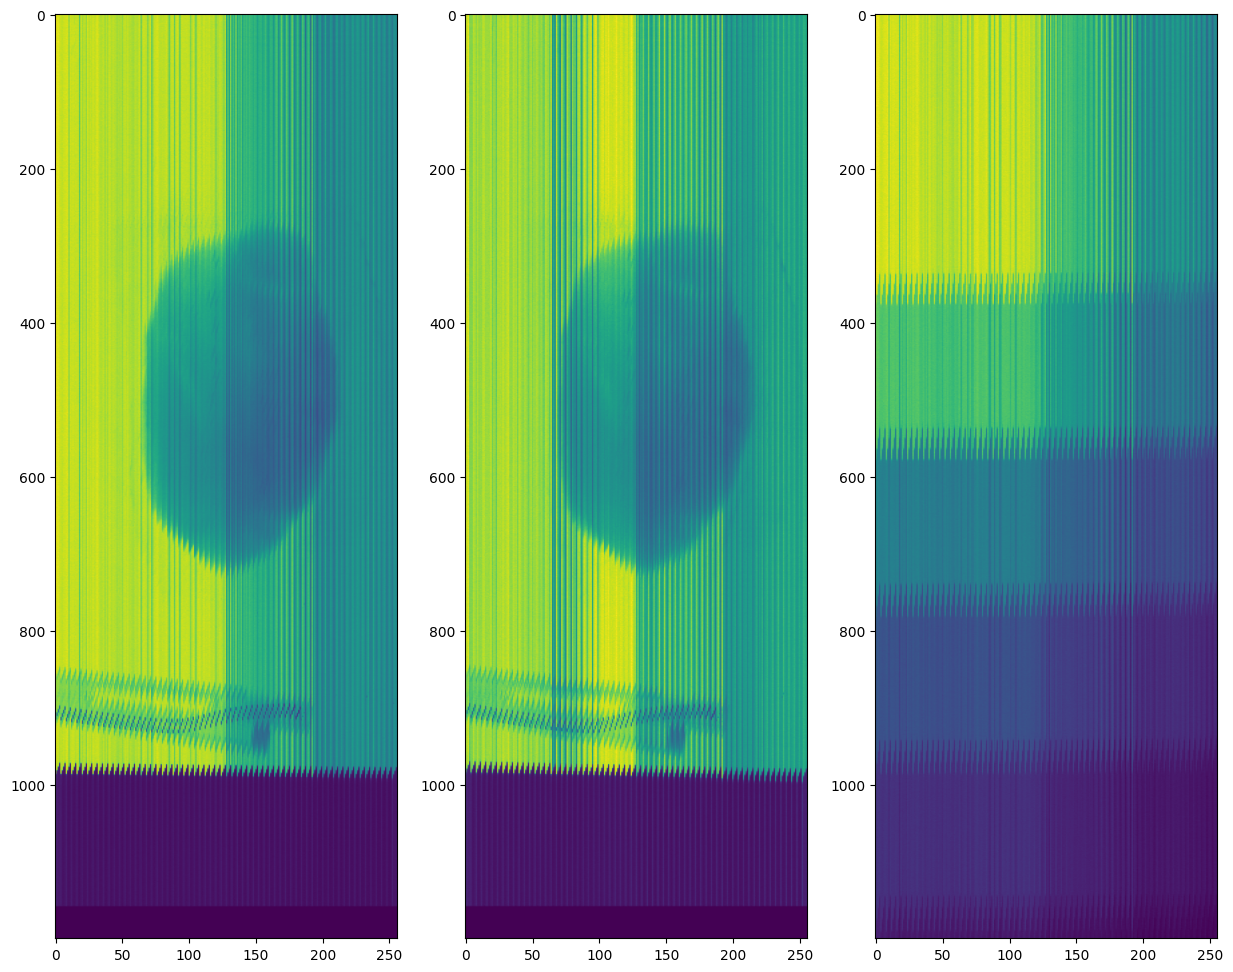

In [11]:
cor_filepath = r"D:\Acq_gui\jirou_air_noBaSO4_30mmps_75kv_4ma_cali_10mspf_sid1000_cor.mat"
cor_pos, cor_data = load_mat_from_file(cor_filepath)
print( cor_data.shape)

cor_filepath1 = r"D:\Acq_gui\jirou_air_30mmps_75kv_4ma_cali_10mspf_sid610_cor.mat"
cor_pos1, cor_data1 = load_mat_from_file(cor_filepath1)
print( cor_data1.shape)

cor_filepath2 = r"X:\labspace\DataCollection\Raw\X-Ray\vplus-data\20260115_exp\bone_detect\fitting_ykl_full3_10mmps_75kv_4ma_cali_10mspf_sid610_cor.mat"
cor_pos2, cor_data2 = load_mat_from_file(cor_filepath2)
print( cor_data2.shape)

fig = plt.figure(figsize=(15, 12))
for i, d in enumerate([cor_data, cor_data1, cor_data2]):

    # norm_data = cor_data[50:200]
    # print(norm_data.shape)
    # norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))

    plt.subplot(1,3,i+1)
    plt.imshow(d[0:1200,:].sum(axis=-1), aspect='auto')
# sag_filepath = r"C:\Users\vplus\Documents\Projects\Acq_gui\ScanTask_600_100mmps_80kv_10ma_cali_10mspf_sid1000_cor.mat"

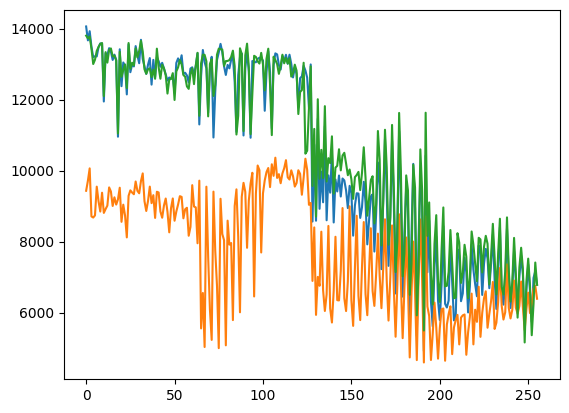

In [3]:
plt.plot(cor_data[200,:,:].sum(axis=-1))
plt.plot(cor_data1[200,:,:].sum(axis=-1))
plt.plot(cor_data2[200,:,:].sum(axis=-1))

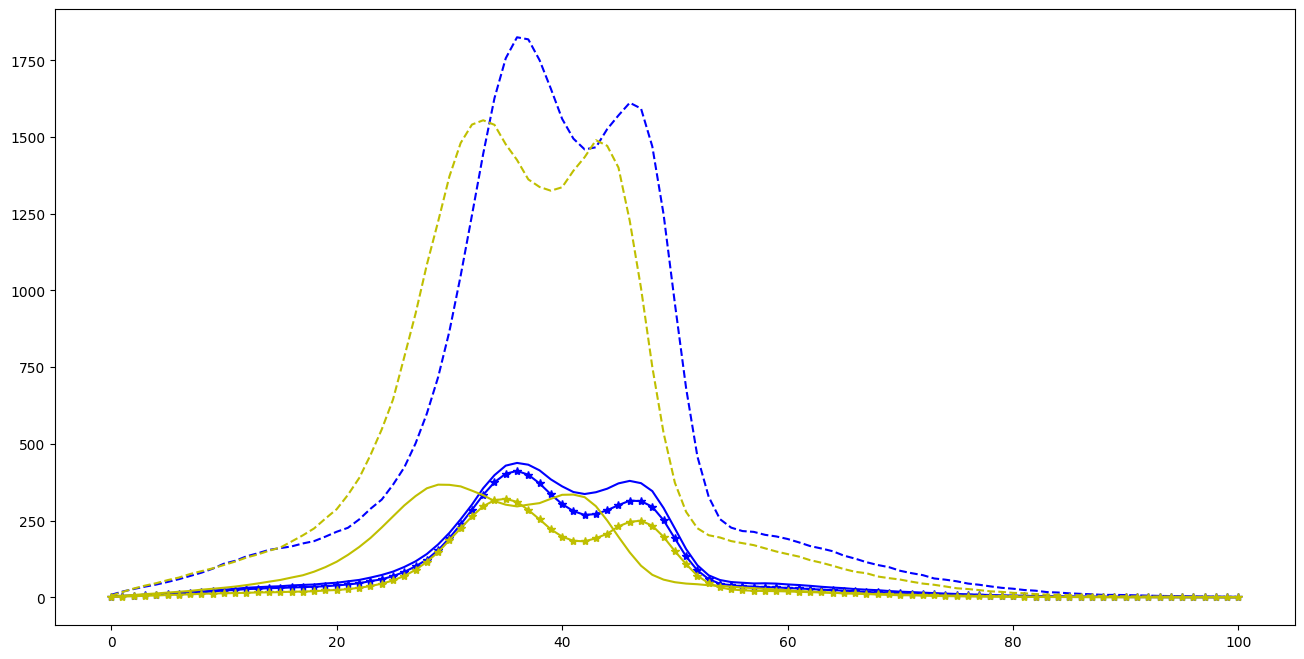

In [4]:
colors = ["r", "g", "b", "y", "k"]
plt.figure(figsize=(16,8))
for cid in range(157,159,1):
    plt.plot(cor_data[0:200,cid,:].mean(axis=0), c = colors[cid%5])
    plt.plot(cor_data1[0:200,cid,:].mean(axis=0),"-*", c = colors[cid%5], )
    plt.plot(cor_data2[0:200,cid,:].mean(axis=0)*4,"--", c = colors[cid%5], )

In [5]:
import os
from tqdm import tqdm

base_dir = r"D:\Acq_gui\bei_acq"
all_pixel_arr = []
for filename in tqdm(os.listdir(base_dir)[:2000]):
    pos_arr, pix_arr = load_mat_from_file(os.path.join(base_dir, filename))
    all_pixel_arr.append(pix_arr)


100%|██████████| 2000/2000 [00:11<00:00, 176.22it/s]


In [6]:

all_pixel_arr2 = np.array(all_pixel_arr)

print(all_pixel_arr2.shape)

(2000, 50, 256, 101)


In [7]:

all_pixel_arr3 = np.vstack(all_pixel_arr)
print(all_pixel_arr3.shape)

(100000, 256, 101)


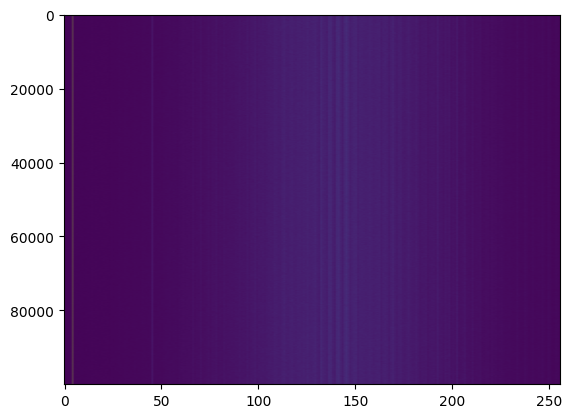

In [8]:

plt.imshow(all_pixel_arr3.sum(axis=2), aspect='auto')

In [9]:
tmp = all_pixel_arr3.sum(axis=0)[:, 10:]

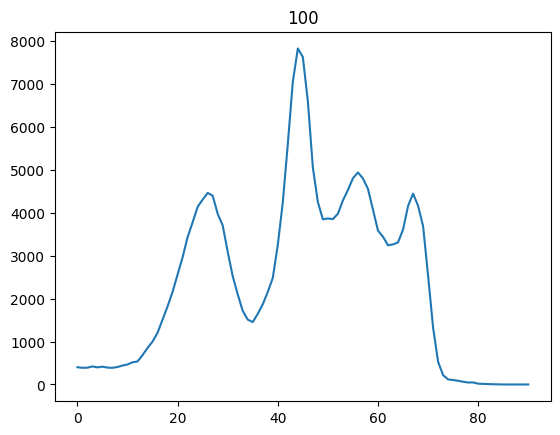

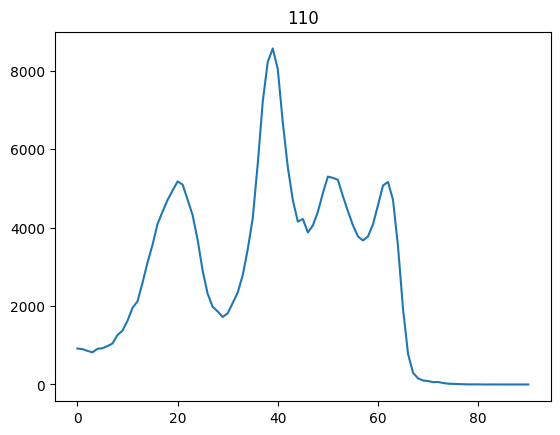

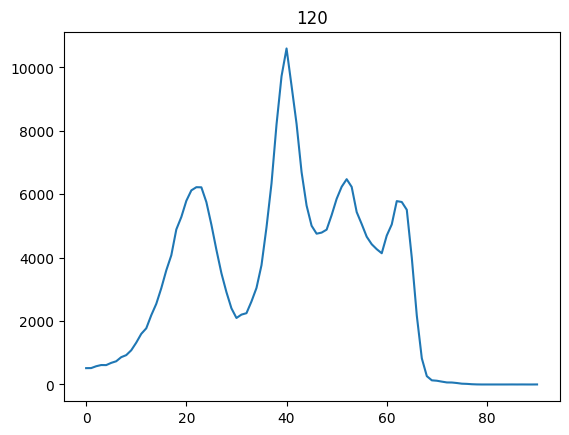

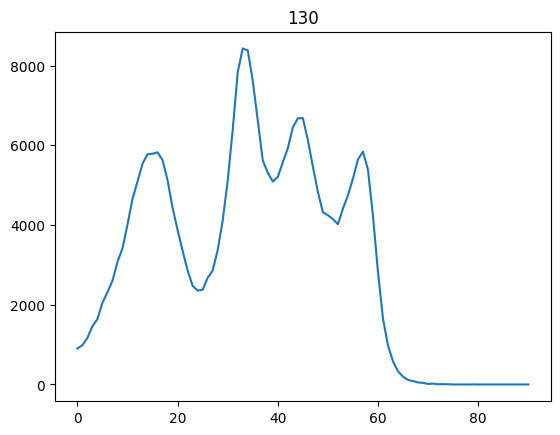

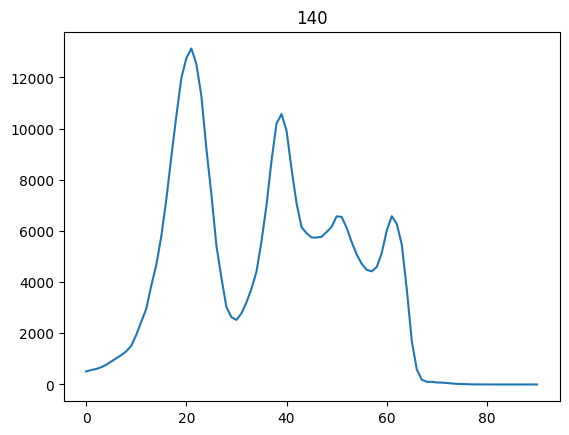

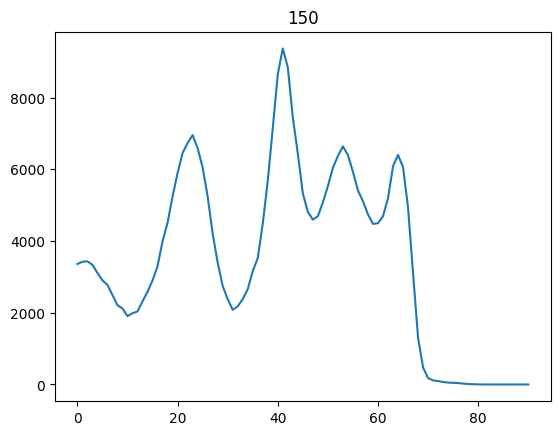

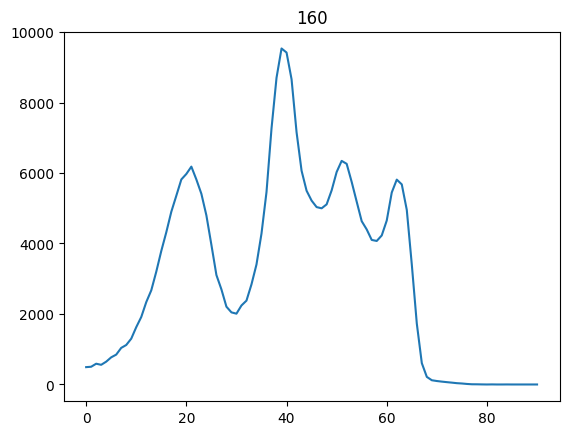

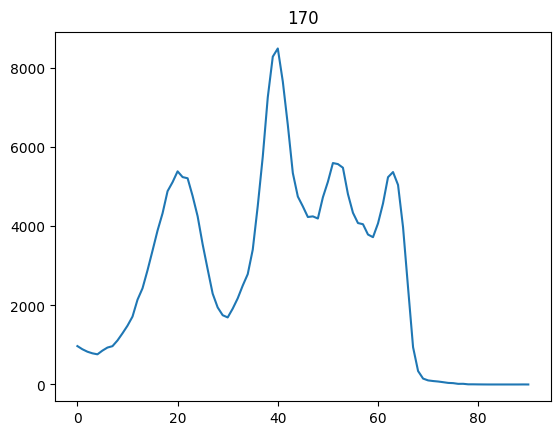

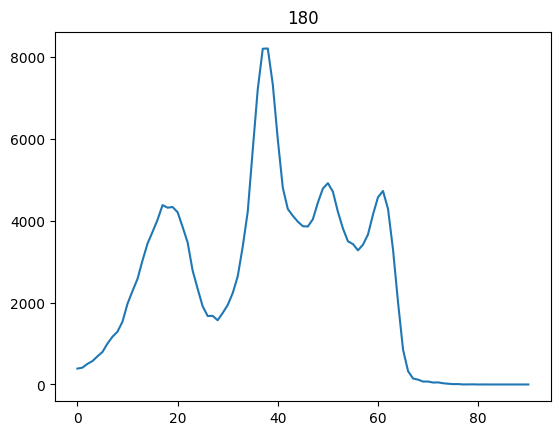

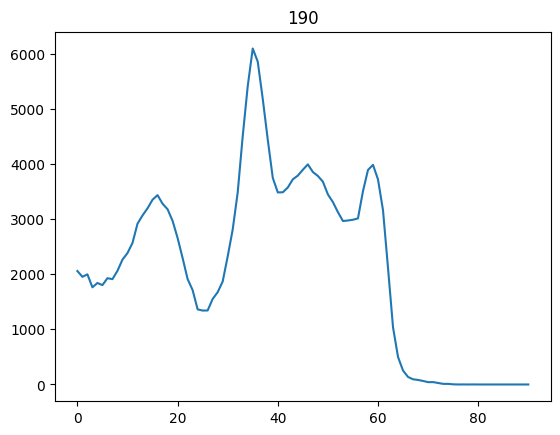

In [10]:
for i in range(100, 200, 10):
    _ = plt.plot(tmp[i].T)
    plt.title(i)
    plt.show()